### Task 1:

In [14]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations

locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph

warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    },

    "Packing_Station": {}
}


# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")
print(f"{'Location':20s}{'Coordinates':>14s}{'h(n)':>10s}")

for location in locations:
    print(f"{location:20s}{str(locations[location]):>14s}{heuristic(location, goal):10.2f}")

Heuristic Values
----------------
Location               Coordinates      h(n)
Receiving_Area              (0, 0)      9.22
Storage_A                   (2, 1)      7.07
Storage_B                   (1, 4)      6.32
Sorting_Area                (4, 2)      5.00
Inspection_Area             (5, 5)      2.24
Packing_Station             (7, 6)      0.00


#### NetworkX visualization:

In [15]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    G.add_node(node)
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 6. Find minimum-cost path

solution_path = nx.shortest_path(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


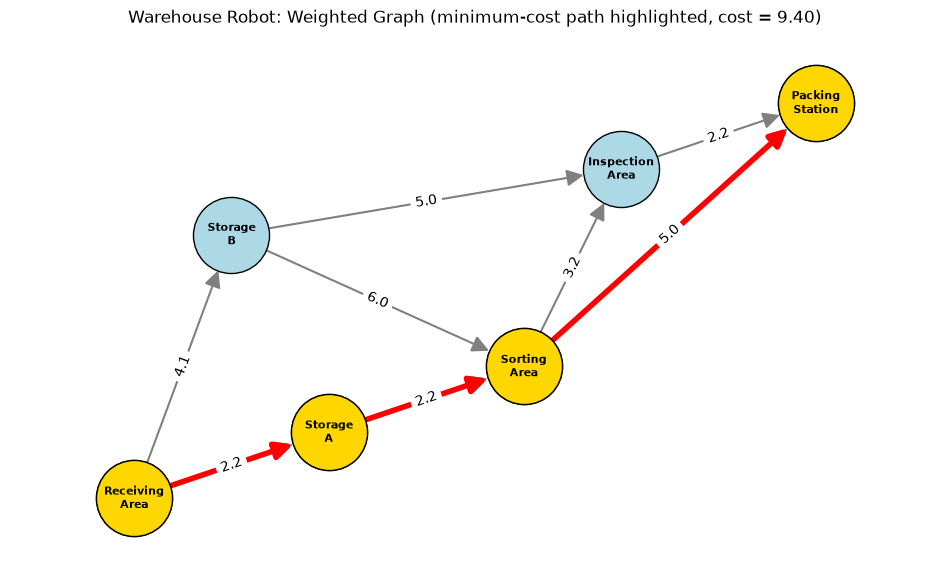

In [16]:
# 7. Visualize graph

pos = locations

plt.figure(figsize=(12, 7))

path_edges = list(zip(solution_path, solution_path[1:]))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=3000)
nx.draw_networkx_nodes(G, pos, nodelist=solution_path, node_color="gold", edgecolors="black", node_size=3000)
nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5, arrowsize=25, node_size=3000)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=4, arrowsize=25, node_size=3000)
nx.draw_networkx_labels(G, pos, labels={n: n.replace("_", "\n") for n in G.nodes}, font_size=8, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=10)

plt.title(f"Warehouse Robot: Weighted Graph (minimum-cost path highlighted, cost = {solution_cost:.2f})")
plt.margins(0.12)
plt.axis("off")
plt.show()

In [17]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("***********************************")
print(f"{'Edge (n -> m)':40s}{'h(n)':>8s}{'cost':>8s}{'h(m)':>8s}{'cost+h(m)':>11s}  Result")

violations = 0

for node in warehouse_graph:

    for neighbor, cost in warehouse_graph[node].items():

        h_n = heuristic(node, goal)
        h_m = heuristic(neighbor, goal)
        holds = h_n <= cost + h_m
        violations += not holds

        print(
            f"{node + ' -> ' + neighbor:40s}"
            f"{h_n:8.3f}{cost:8.1f}{h_m:8.3f}{cost + h_m:11.3f}"
            f"  {'Satisfied' if holds else 'Violated'}"
        )

print(f"\nEdges satisfying h(n) <= cost(n,m) + h(m): {G.number_of_edges() - violations} of {G.number_of_edges()}")


Heuristic Condition Verification
***********************************
Edge (n -> m)                               h(n)    cost    h(m)  cost+h(m)  Result
Receiving_Area -> Storage_A                9.220     2.2   7.071      9.271  Satisfied
Receiving_Area -> Storage_B                9.220     4.1   6.325     10.425  Satisfied
Storage_A -> Sorting_Area                  7.071     2.2   5.000      7.200  Satisfied
Storage_B -> Inspection_Area               6.325     5.0   2.236      7.236  Satisfied
Storage_B -> Sorting_Area                  6.325     6.0   5.000     11.000  Satisfied
Sorting_Area -> Inspection_Area            5.000     3.2   2.236      5.436  Satisfied
Sorting_Area -> Packing_Station            5.000     5.0   0.000      5.000  Satisfied
Inspection_Area -> Packing_Station         2.236     2.2   0.000      2.200  Violated

Edges satisfying h(n) <= cost(n,m) + h(m): 7 of 8


### Task 2:

In [18]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph

airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


# 4. GBFS: f(n) = h(n)

def greedy_best_first_search(start, goal, graph):

    frontier = [(heuristic(start, goal), 0, start)]
    came_from = {start: None}
    explored = set()
    expansion_order = []
    counter = 1

    while frontier:

        _, _, current = heapq.heappop(frontier)

        if current in explored:
            continue

        explored.add(current)
        expansion_order.append(current)

        if current == goal:

            # Reconstruct path
            path = []
            node = current
            while node is not None:
                path.append(node)
                node = came_from[node]
            path.reverse()

            # Calculate actual path cost
            total_cost = sum(graph[a][b] for a, b in zip(path, path[1:]))

            return path, total_cost, expansion_order

        for neighbor in graph[current]:

            if neighbor not in explored and neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(frontier, (heuristic(neighbor, goal), counter, neighbor))
                counter += 1

    return None, float("inf"), expansion_order


# 5. Run GBFS

start = "Baggage_Area"
goal = "Departure_Gate"

path, total_cost, expansion_order = greedy_best_first_search(start, goal, airport_graph)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

print("\nHeuristic values h(n) to Departure_Gate:")
for node in locations:
    print(f"  {node:16s}{heuristic(node, goal):6.2f}")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30

Heuristic values h(n) to Departure_Gate:
  Baggage_Area     10.00
  Security          7.81
  Checkpoint        7.28
  Food_Court        5.66
  Terminal_Hall     3.16
  Departure_Gate    0.00


#### NetworkX visualization

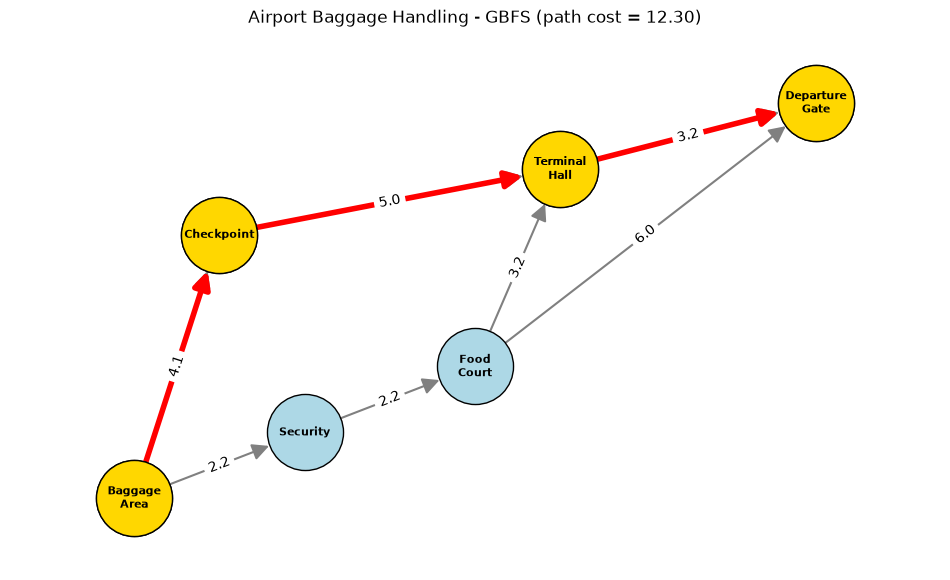

In [19]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    G.add_node(node)
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)


pos = locations

plt.figure(figsize=(12, 7))

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=3000)
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="gold", edgecolors="black", node_size=3000)
nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5, arrowsize=25, node_size=3000)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=4, arrowsize=25, node_size=3000)
nx.draw_networkx_labels(G, pos, labels={n: n.replace("_", "\n") for n in G.nodes}, font_size=8, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=10)

plt.title(f"Airport Baggage Handling - GBFS (path cost = {total_cost:.2f})")
plt.margins(0.12)
plt.axis("off")
plt.show()

### Task 3:

In [20]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates


locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph


hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    },

    "Emergency_Ward": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):

    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

# 4. Path reconstruction

def reconstruct_path(came_from, current):

    path = []
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

# 5. A* Search: f(n) = g(n) + h(n)

def a_star_search(start, goal, graph):

    g_cost = {start: 0}
    came_from = {start: None}
    frontier = [(heuristic(start, goal), 0, 0, start)]
    counter = 1
    expansion_order = []

    while frontier:

        f, _, g, current = heapq.heappop(frontier)

        if g > g_cost[current]:
            continue

        expansion_order.append(current)

        if current == goal:
            return reconstruct_path(came_from, current), g_cost[current], expansion_order, g_cost

        for neighbor, cost in graph[current].items():

            tentative_g = g_cost[current] + cost

            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                f_neighbor = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(frontier, (f_neighbor, counter, tentative_g, neighbor))
                counter += 1

    return None, float("inf"), expansion_order, g_cost

# 6. Run A*

start = "Pharmacy"
goal = "Emergency_Ward"

path, total_cost, expansion_order, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [21]:
# you may also replace it with dataframe it is completely your own choice

print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:

    g = g_cost[node]
    h = heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

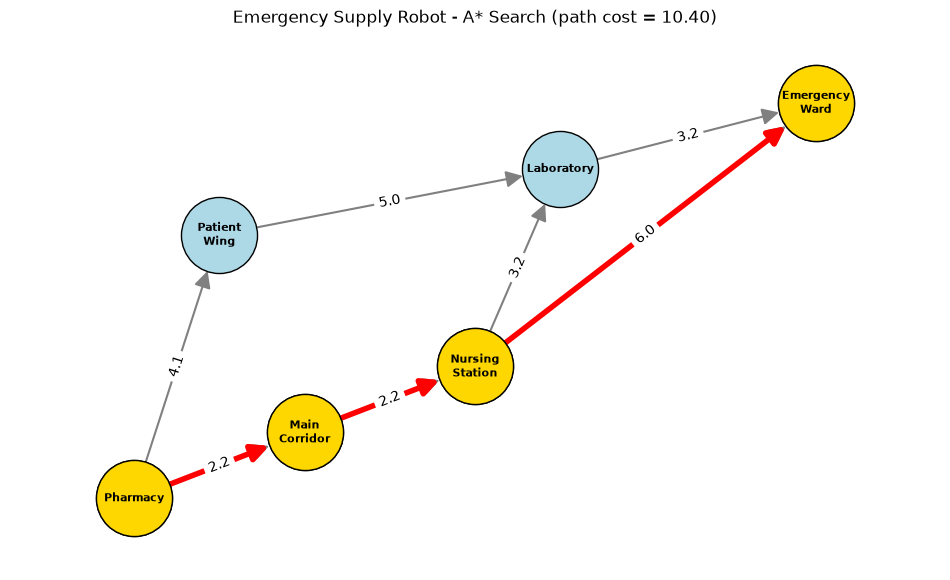

In [22]:
# 7. NetworkX visualization
G = nx.DiGraph()

for node, neighbors in hospital_graph.items():
    G.add_node(node)
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)


pos = locations

plt.figure(figsize=(12, 7))

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=3000)
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="gold", edgecolors="black", node_size=3000)
nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5, arrowsize=25, node_size=3000)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=4, arrowsize=25, node_size=3000)
nx.draw_networkx_labels(G, pos, labels={n: n.replace("_", "\n") for n in G.nodes}, font_size=8, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=10)

plt.title(f"Emergency Supply Robot - A* Search (path cost = {total_cost:.2f})")
plt.margins(0.12)
plt.axis("off")
plt.show()

#### GBFS vs A* on the same hospital graph

In [23]:
gbfs_path, gbfs_cost, gbfs_order = greedy_best_first_search(start, goal, hospital_graph)

for name, p, c, order in [("GBFS", gbfs_path, gbfs_cost, gbfs_order), ("A*", path, total_cost, expansion_order)]:
    print(f"{name}")
    print(f"  Expansion order: {' -> '.join(order)}")
    print(f"  Solution path  : {' -> '.join(p)}")
    print(f"  Total cost     : {c:.2f}\n")

GBFS
  Expansion order: Pharmacy -> Patient_Wing -> Laboratory -> Emergency_Ward
  Solution path  : Pharmacy -> Patient_Wing -> Laboratory -> Emergency_Ward
  Total cost     : 12.30

A*
  Expansion order: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
  Solution path  : Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
  Total cost     : 10.40



### Task 4:

In [24]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },

    "Zone_C": {
        "Zone_D": 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    },

    "Customer_Building": {}
}

# 3. Euclidean Heuristic

def heuristic(node, goal):

    x1, y1 = locations[node]
    x2, y2 = locations[goal]
    return round(math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2))

# 4. Display Heuristic Values
goal = "Customer_Building"

heuristic_data = []

for node in locations:

    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)


def weighted_a_star(start, goal, graph, weight):

    g_cost = {start: 0}
    came_from = {start: None}
    frontier = [(weight * heuristic(start, goal), 0, 0, start)]
    counter = 1
    expansion_order = []

    while frontier:

        f, _, g, current = heapq.heappop(frontier)

        if g > g_cost[current]:
            continue

        expansion_order.append(current)

        if current == goal:

            path = []
            node = current
            while node is not None:
                path.append(node)
                node = came_from[node]
            path.reverse()

            return path, g_cost[current], expansion_order

        for neighbor, cost in graph[current].items():

            tentative_g = g_cost[current] + cost

            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                f_neighbor = tentative_g + weight * heuristic(neighbor, goal)
                heapq.heappush(frontier, (f_neighbor, counter, tentative_g, neighbor))
                counter += 1

    return None, float("inf"), expansion_order

# 6. Run Weighted A* for All Required Weights
start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:

    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })


# 7. Display Results in dataframe

results_df = pd.DataFrame(results)

print("\nWeighted A* Results (w = 1 is normal A*):")
print(results_df[["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]].to_string(index=False))

# 8. Display Detailed Expansion Orders

print("\nExpansion Orders:")
for row in results:
    print(f"w = {row['Weight']}: {row['Expansion Order']}")

Heuristic Values:
               Node  h(n)
Distribution_Center    10
             Zone_A     8
             Zone_B     7
             Zone_C     6
             Zone_D     3
  Customer_Building     0

Weighted A* Results (w = 1 is normal A*):
 Weight                                             Solution Path  Total Cost  Nodes Expanded
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5
    1.5 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4

Expansion Orders:
w = 1: Distribution_Center → Zone_B → Zone_A → Zone_C → Customer_Building
w = 1.5: Distribution_Center → Zone_B → Zone_D → Customer_Building
w = 2: Distribution_Center → Zone_B → Zone_D → Customer_Building
w = 3: Distribution_Center → Zone_B → Zone_D → Customer_Buildi

#### NetworkX visualization

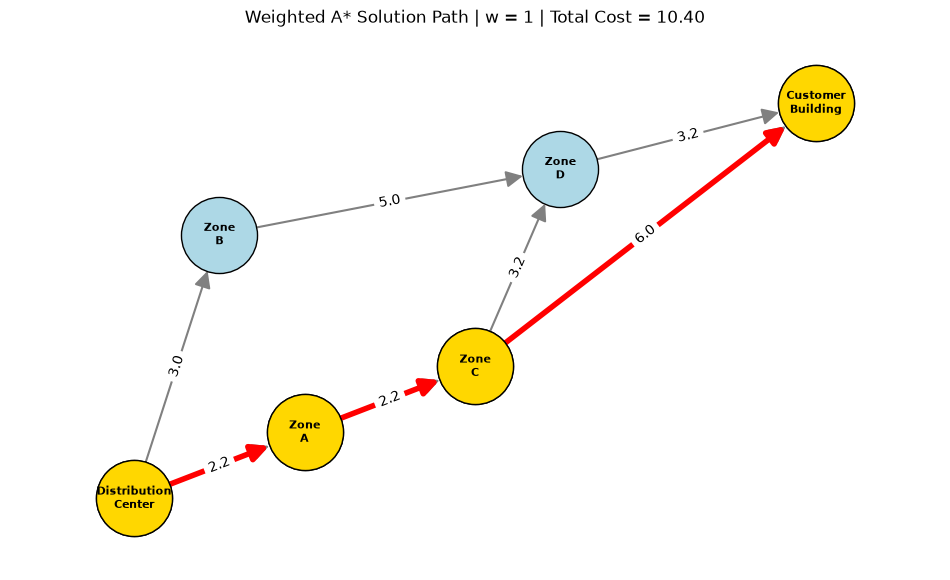

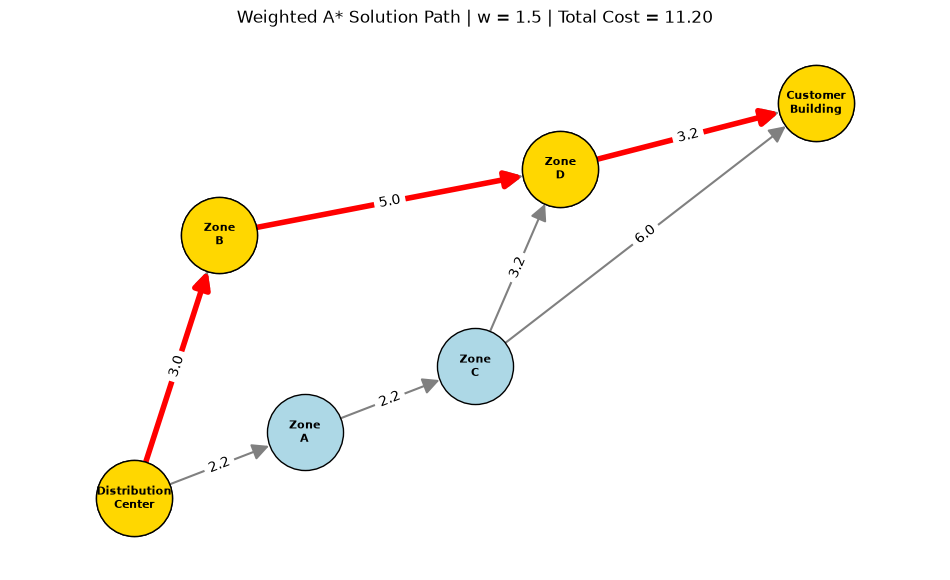

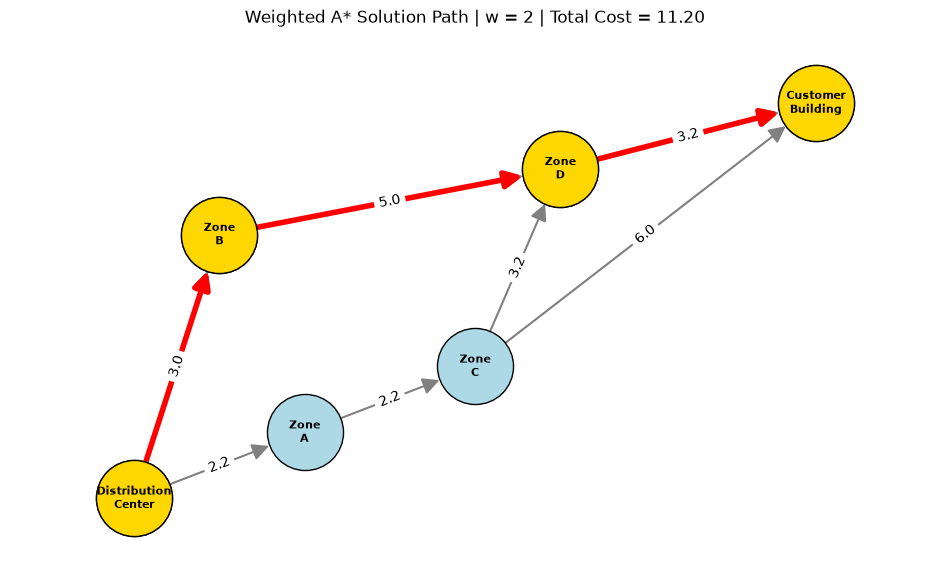

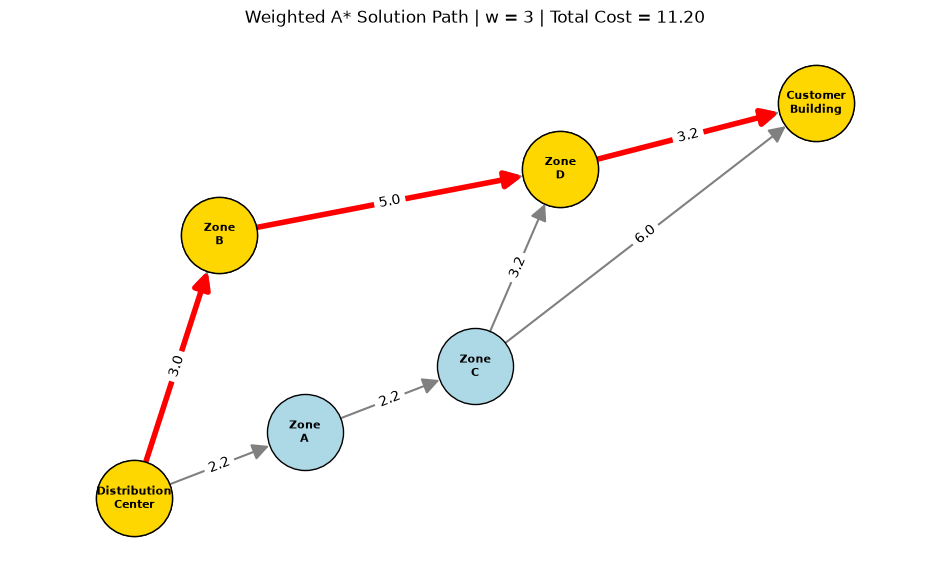

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph

G = nx.DiGraph()

# Add nodes with their coordinates
for node, position in locations.items():

    G.add_node(
        node,
        pos=position
    )


# Add weighted edges
for node, neighbors in graph.items():

    for neighbor, cost in neighbors.items():

        G.add_edge(node, neighbor, weight=cost)

# 2. Node Positions
pos = locations

# 3. Visualize Weighted A* Result for Each Weight

for w in weights:

    # Run Weighted A*
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)
    path_edges = list(zip(path, path[1:]))

    plt.figure(figsize=(12, 7))

    nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=3000)
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="gold", edgecolors="black", node_size=3000)
    nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5, arrowsize=25, node_size=3000)
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=4, arrowsize=25, node_size=3000)
    nx.draw_networkx_labels(G, pos, labels={n: n.replace("_", "\n") for n in G.nodes}, font_size=8, font_weight="bold")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=10)

    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.margins(0.12)
    plt.axis("off")

    plt.show()